# 1. Context and Medical Disclaimer

This notebook builds a Clinical Decision Support System prototype using the Breast Cancer Wisconsin Diagnostic dataset (1995, Wolberg). It is not a diagnostic device and must not be used for clinical decisions without expert oversight.

Key cautions:
- The dataset is a small historical snapshot (569 samples) and does not represent modern, diverse populations.
- Model outputs are risk signals for research and education, not definitive diagnoses.
- False negatives are clinically unacceptable; recall for malignant cases is the primary optimization target.

# 2. Data Loading and Target Inversion

We load the dataset dynamically from scikit-learn and invert the target so Malignant = 1 and Benign = 0. This aligns with clinical convention where the high-risk class is positive.

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer(as_frame=True)
X = data.data.copy()
y = data.target.copy()

# Invert so malignant=1 and benign=0.
y = 1 - y
y.name = "diagnosis"

df = X.copy()
df["diagnosis"] = y

y.value_counts()

diagnosis
0    357
1    212
Name: count, dtype: int64

# 3. EDA and Target-Aware Multicollinearity Filter

We identify strongly correlated feature pairs (|r| > 0.85) and drop the feature with the weaker absolute correlation to the malignant target.

In [2]:
from IPython.display import display

threshold = 0.85

class_summary = pd.DataFrame(
    {
        "count": y.value_counts(),
        "ratio": y.value_counts(normalize=True),
    }
).rename(index={0: "benign", 1: "malignant"})

target_corr = X.apply(lambda col: col.corr(y)).abs().sort_values(ascending=False)

corr_matrix = X.corr()
abs_corr_matrix = corr_matrix.abs()

upper = abs_corr_matrix.where(np.triu(np.ones(abs_corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = upper.stack().sort_values(ascending=False)
high_corr_pairs = high_corr_pairs[high_corr_pairs > threshold]

drops = set()
for (feat_a, feat_b), corr_value in high_corr_pairs.items():
    if feat_a in drops or feat_b in drops:
        continue
    corr_a = abs(X[feat_a].corr(y))
    corr_b = abs(X[feat_b].corr(y))
    drop = feat_a if corr_a < corr_b else feat_b
    drops.add(drop)

dropped_features = sorted(drops)
X_filtered = X.drop(columns=dropped_features)

df_filtered = X_filtered.copy()
df_filtered["diagnosis"] = y

print(f"High-correlation pairs (> {threshold}): {len(high_corr_pairs)}")
print(f"Dropped features: {len(dropped_features)}")
display(class_summary)
display(target_corr.head(10))

High-correlation pairs (> 0.85): 29
Dropped features: 12


,count,ratio
diagnosis,,
benign,357,0.627417
malignant,212,0.372583


worst concave points    0.793566
worst perimeter         0.782914
mean concave points     0.776614
worst radius            0.776454
mean perimeter          0.742636
worst area              0.733825
mean radius             0.730029
mean area               0.708984
mean concavity          0.696360
worst concavity         0.659610
dtype: float64

# 4. Stratified Data Splitting

We use an 80/20 split with stratification to preserve the malignant/benign ratio.

In [ ]:
from pathlib import Path
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

BASE_DIR = Path.cwd()
if BASE_DIR.name == "notebooks":
    BASE_DIR = BASE_DIR.parent

OUTPUT_FIGURES = BASE_DIR / "outputs" / "figures"
OUTPUT_METRICS = BASE_DIR / "outputs" / "metrics"
OUTPUT_FIGURES.mkdir(parents=True, exist_ok=True)
OUTPUT_METRICS.mkdir(parents=True, exist_ok=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_filtered,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

split_summary = pd.DataFrame(
    {
        "train_ratio": y_train.value_counts(normalize=True),
        "test_ratio": y_test.value_counts(normalize=True),
    }
).rename(index={0: "benign", 1: "malignant"})

split_summary

,train_ratio,test_ratio
diagnosis,,
benign,0.626374,0.631579
malignant,0.373626,0.368421


# 5. Pipeline Construction (Scaling + Estimators)

All models that require scaling are wrapped in a StandardScaler pipeline to prevent data leakage.

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

logreg_pipe = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "logreg",
            LogisticRegression(
                solver="saga",
                l1_ratio=0.5,
                max_iter=5000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)
svm_pipe = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("svm", SVC(random_state=RANDOM_STATE)),
    ]
)
knn_pipe = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier()),
    ]
)
dt_pipe = Pipeline(
    [
        ("model", DecisionTreeClassifier(random_state=RANDOM_STATE)),
    ]
)
rf_pipe = Pipeline(
    [
        ("model", RandomForestClassifier(random_state=RANDOM_STATE)),
    ]
)

estimators = {
    "Logistic Regression": logreg_pipe,
    "SVM": svm_pipe,
    "KNN": knn_pipe,
    "Decision Tree": dt_pipe,
    "Random Forest": rf_pipe,
}

list(estimators.keys())

['Logistic Regression', 'SVM', 'KNN', 'Decision Tree', 'Random Forest']

# 6. Cross-Validation and Hyperparameter Tuning

We tune each model using GridSearchCV with 5-fold StratifiedKFold and optimize for recall to minimize false negatives.

In [12]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

param_grids = {
    "Logistic Regression": {
        "logreg__C": [0.1, 1.0, 10.0],
        "logreg__l1_ratio": [0.0, 1.0],
        "logreg__class_weight": [None, "balanced"],
    },
    "SVM": [
        {
            "svm__kernel": ["linear"],
            "svm__C": [0.1, 1.0, 10.0],
            "svm__class_weight": [None, "balanced"],
        },
        {
            "svm__kernel": ["rbf"],
            "svm__C": [0.1, 1.0, 10.0],
            "svm__gamma": ["scale", "auto"],
            "svm__class_weight": [None, "balanced"],
        },
    ],
    "KNN": {
        "knn__n_neighbors": [3, 5, 7, 9],
        "knn__weights": ["uniform", "distance"],
        "knn__p": [1, 2],
    },
    "Decision Tree": {
        "model__max_depth": [None, 3, 5, 7],
        "model__min_samples_split": [2, 5],
        "model__min_samples_leaf": [1, 2],
        "model__class_weight": [None, "balanced"],
    },
    "Random Forest": {
        "model__n_estimators": [200, 400],
        "model__max_depth": [None, 5, 10],
        "model__min_samples_split": [2, 5],
        "model__min_samples_leaf": [1, 2],
        "model__class_weight": [None, "balanced"],
    },
}

searches = {}
for name, estimator in estimators.items():
    grid = GridSearchCV(
        estimator,
        param_grids[name],
        scoring="recall",
        cv=cv,
        n_jobs=-1,
        refit=True,
    )
    grid.fit(X_train, y_train)
    searches[name] = grid

best_estimators = {name: grid.best_estimator_ for name, grid in searches.items()}

best_params_df = pd.DataFrame(
    [
        {
            "model": name,
            "cv_recall": grid.best_score_,
            "best_params": grid.best_params_,
        }
        for name, grid in searches.items()
    ]
).sort_values(by="cv_recall", ascending=False)

best_params_df.to_csv(OUTPUT_METRICS / "gridsearch_best_params.csv", index=False)
best_params_df

,model,cv_recall,best_params
1,SVM,0.964706,"{'svm__C': 10.0, 'svm__class_weight': 'balance..."
0,Logistic Regression,0.958824,"{'logreg__C': 1.0, 'logreg__class_weight': 'ba..."
4,Random Forest,0.929412,"{'model__class_weight': 'balanced', 'model__ma..."
2,KNN,0.911765,"{'knn__n_neighbors': 7, 'knn__p': 2, 'knn__wei..."
3,Decision Tree,0.900000,"{'model__class_weight': 'balanced', 'model__ma..."


# 7. Model Comparison (ROC-AUC and Metrics)

We compare tuned models using cross-validated out-of-fold predictions on the training set, then export the metric table and ROC curves.

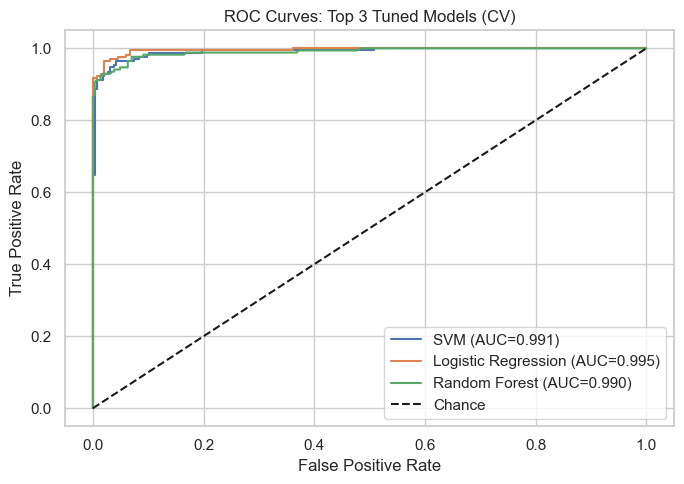

,model,recall,f1,roc_auc,specificity
0,SVM,0.964706,0.947977,0.991146,0.957895
1,Logistic Regression,0.958824,0.961652,0.995418,0.978947
2,Random Forest,0.929412,0.946108,0.990392,0.978947
3,KNN,0.911765,0.948012,0.981558,0.992982
4,Decision Tree,0.900000,0.908012,0.925697,0.950877


In [13]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, f1_score, recall_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

model_metrics = []
oof_probas = {}

for name, estimator in best_estimators.items():
    y_pred = cross_val_predict(
        estimator,
        X_train,
        y_train,
        cv=cv,
        method="predict",
        n_jobs=-1,
    )
    if hasattr(estimator, "predict_proba"):
        y_score = cross_val_predict(
            estimator,
            X_train,
            y_train,
            cv=cv,
            method="predict_proba",
            n_jobs=-1,
        )[:, 1]
    elif hasattr(estimator, "decision_function"):
        y_score = cross_val_predict(
            estimator,
            X_train,
            y_train,
            cv=cv,
            method="decision_function",
            n_jobs=-1,
        )
    else:
        y_score = y_pred
    tn, fp, fn, tp = confusion_matrix(y_train, y_pred).ravel()
    specificity = tn / (tn + fp)
    model_metrics.append(
        {
            "model": name,
            "recall": recall_score(y_train, y_pred),
            "f1": f1_score(y_train, y_pred),
            "roc_auc": roc_auc_score(y_train, y_score),
            "specificity": specificity,
        }
    )
    oof_probas[name] = y_score

metrics_df = (
    pd.DataFrame(model_metrics)
    .sort_values(by="recall", ascending=False)
    .reset_index(drop=True)
)
metrics_df.to_csv(OUTPUT_METRICS / "model_comparison.csv", index=False)

top_models = metrics_df["model"].head(3).tolist()

plt.figure(figsize=(7, 5))
for name in top_models:
    fpr, tpr, _ = roc_curve(y_train, oof_probas[name])
    auc = roc_auc_score(y_train, oof_probas[name])
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves: Top 3 Tuned Models (CV)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES / "roc_curves_top3.png", dpi=300)
plt.show()

metrics_df

# 8. Final Evaluation on Test Set

We evaluate the best model once on the held-out test set, compute clinical metrics, and generate a confusion matrix with false negatives highlighted.

Selected model: SVM
Test recall (malignant=1): 0.905
Test F1: 0.938
Test ROC-AUC: 0.991
Test specificity: 0.986
False negatives: 4


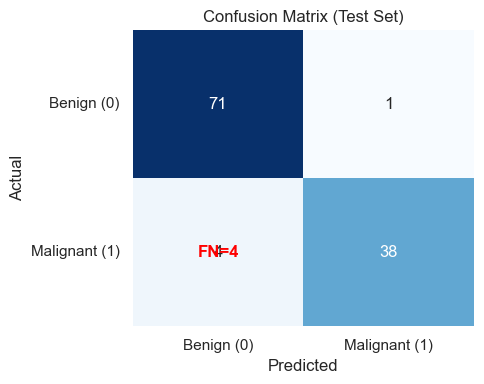

In [14]:
from sklearn.metrics import classification_report

best_model_name = metrics_df.loc[0, "model"]
best_model = best_estimators[best_model_name]

best_model.fit(X_train, y_train)

y_test_pred = best_model.predict(X_test)
if hasattr(best_model, "predict_proba"):
    y_test_score = best_model.predict_proba(X_test)[:, 1]
elif hasattr(best_model, "decision_function"):
    y_test_score = best_model.decision_function(X_test)
else:
    y_test_score = y_test_pred

cm = confusion_matrix(y_test, y_test_pred)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)

report_df = pd.DataFrame(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["benign (0)", "malignant (1)"],
        output_dict=True,
        zero_division=0,
    )
).transpose()

report_df.to_csv(OUTPUT_METRICS / "classification_report.csv", index=True)

print(f"Selected model: {best_model_name}")
print(f"Test recall (malignant=1): {recall_score(y_test, y_test_pred):.3f}")
print(f"Test F1: {f1_score(y_test, y_test_pred):.3f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_test_score):.3f}")
print(f"Test specificity: {specificity:.3f}")
print(f"False negatives: {fn}")

plt.figure(figsize=(5, 4))
ax = sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_xticklabels(["Benign (0)", "Malignant (1)"])
ax.set_yticklabels(["Benign (0)", "Malignant (1)"], rotation=0)
ax.text(0.5, 1.5, f"FN={fn}", ha="center", va="center", color="red", fontweight="bold")
plt.title("Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES / "confusion_matrix.png", dpi=300)
plt.show()

# 9. Feature Importance (Logistic Regression)

We extract absolute coefficients from the tuned Logistic Regression model to identify the most influential biological features for malignancy.

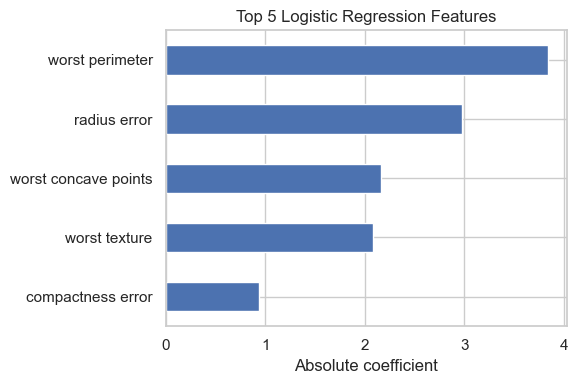

worst perimeter         3.838452
radius error            2.971887
worst concave points    2.158155
worst texture           2.084708
compactness error       0.940467
dtype: float64

In [15]:
logreg_model = best_estimators["Logistic Regression"]
logreg_model.fit(X_train, y_train)

coefficients = logreg_model.named_steps["logreg"].coef_[0]
feature_importance = (
    pd.Series(np.abs(coefficients), index=X_filtered.columns)
    .sort_values(ascending=False)
)
feature_importance.to_csv(
    OUTPUT_METRICS / "logreg_feature_importance.csv",
    header=["abs_coefficient"],
)

top_features = feature_importance.head(5)

plt.figure(figsize=(6, 4))
top_features.sort_values().plot(kind="barh")
plt.xlabel("Absolute coefficient")
plt.title("Top 5 Logistic Regression Features")
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES / "logreg_top5_features.png", dpi=300)
plt.show()

top_features

# 10. Technical and Clinical Conclusions

- The pipeline prioritizes malignant recall at every stage using stratified CV and recall-optimized tuning.
- The final model is selected from CV comparisons and evaluated once on the held-out test set to quantify false negatives.
- All artifacts (metrics tables and figures) are exported to outputs/metrics and outputs/figures for poster use.
- Interpretability is supported through logistic regression feature importance after multicollinearity filtering.
- Limitations: small historical dataset, limited diversity, and no external validation; results cannot be generalized to modern clinical populations.
- This notebook is a research prototype and must not be used as a standalone diagnostic tool.